<a href="https://colab.research.google.com/github/ksantos-helo/Challenge---TelecomX_BR/blob/main/Telecom_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 1. Importação das bibliotecas


In [ ]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns


# 2. Extração de dados (API)

In [ ]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()


In [ ]:
df = pd.json_normalize(data)


#3.Explorar as colunas do dataset

In [ ]:
df.head()


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
df.shape


(7267, 21)

In [ ]:
df.columns



Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [ ]:
for coluna in df.columns:
    print(coluna)


customerID
Churn
customer.gender
customer.SeniorCitizen
customer.Partner
customer.Dependents
customer.tenure
phone.PhoneService
phone.MultipleLines
internet.InternetService
internet.OnlineSecurity
internet.OnlineBackup
internet.DeviceProtection
internet.TechSupport
internet.StreamingTV
internet.StreamingMovies
account.Contract
account.PaperlessBilling
account.PaymentMethod
account.Charges.Monthly
account.Charges.Total


In [ ]:
for coluna in df.select_dtypes(include='object').columns:
    print(f"\n{coluna}")
    print(df[coluna].value_counts())



customerID
customerID
9995-HOTOH    1
0002-ORFBO    1
0003-MKNFE    1
9970-QBCDA    1
9968-FFVVH    1
             ..
0014-BMAQU    1
0013-SMEOE    1
0013-MHZWF    1
0013-EXCHZ    1
0011-IGKFF    1
Name: count, Length: 7267, dtype: int64

Churn
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

customer.gender
customer.gender
Male      3675
Female    3592
Name: count, dtype: int64

customer.Partner
customer.Partner
No     3749
Yes    3518
Name: count, dtype: int64

customer.Dependents
customer.Dependents
No     5086
Yes    2181
Name: count, dtype: int64

phone.PhoneService
phone.PhoneService
Yes    6560
No      707
Name: count, dtype: int64

phone.MultipleLines
phone.MultipleLines
No                  3495
Yes                 3065
No phone service     707
Name: count, dtype: int64

internet.InternetService
internet.InternetService
Fiber optic    3198
DSL            2488
No             1581
Name: count, dtype: int64

internet.OnlineSecurity
internet.OnlineSecurity
No  

In [ ]:
df.isnull().sum()


,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


#4.Verificar os tipos de dados

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [ ]:
df.dtypes


,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


#5. Dicionário de dados

customerID: número de identificação único de cada cliente

Churn: se o cliente deixou ou não a empresa

gender: gênero (masculino e feminino)

SeniorCitizen: informação sobre um cliente ter ou não idade igual ou maior que 65 anos

Partner: se o cliente possui ou não um parceiro ou parceira

Dependents: se o cliente possui ou não dependentes

tenure: meses de contrato do cliente

PhoneService: assinatura de serviço telefônico

MultipleLines: assisnatura de mais de uma linha de telefone

InternetService: assinatura de um provedor internet

OnlineSecurity: assinatura adicional de segurança online

OnlineBackup: assinatura adicional de backup online

DeviceProtection: assinatura adicional de proteção no dispositivo

TechSupport: assinatura adicional de suporte técnico, menos tempo de espera

StreamingTV: assinatura de TV a cabo

StreamingMovies: assinatura de streaming de filmes

Contract: tipo de contrato

PaperlessBilling: se o cliente prefere receber online a fatura

PaymentMethod: forma de pagamento

Charges.Monthly: total de todos os serviços do cliente por mês

Charges.Total: total gasto pelo cliente


#6.Separar variáveis por categoria (baseado no dicionário)

In [ ]:
demograficas = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents'
]


In [ ]:
servicos = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]


In [ ]:
conta = [
    'tenure',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]


In [ ]:
financeiro = [
    'Charges.Monthly',
    'Charges.Total'
]


In [ ]:
target = 'Churn'


#7. Verificar Distribuicao do Churn

In [ ]:
df['Churn'].value_counts()


,count
Churn,
No,5174
Yes,1869
,224


In [ ]:
df['Churn'].value_counts(normalize=True) * 100


,proportion
Churn,
No,71.198569
Yes,25.719004
,3.082427


#8.Verificar estatísticas das **variáveis**

In [ ]:
df.describe()


,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [ ]:
df.describe(include='all')


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
count,7267,7267,7267,7267.000000,7267,7267,7267.000000,7267,7267,7267,...,7267,7267,7267,7267,7267,7267,7267,7267,7267.000000,7267
unique,7267,3,2,NaN,2,2,NaN,2,3,3,...,3,3,3,3,3,3,2,4,NaN,6531
top,9995-HOTOH,No,Male,NaN,No,No,NaN,Yes,No,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2
freq,1,5174,3675,NaN,3749,5086,NaN,6560,3495,3198,...,3182,3195,3582,2896,2870,4005,4311,2445,NaN,11
mean,NaN,NaN,NaN,0.162653,NaN,NaN,32.346498,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.720098,NaN
std,NaN,NaN,NaN,0.369074,NaN,NaN,24.571773,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.129572,NaN
min,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN
25%,NaN,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.425000,NaN
50%,NaN,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.300000,NaN
75%,NaN,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.875000,NaN


# 9. Transformação dos dados

# 10. Análise Exploratória (EDA)

# 11. Visualização de dados

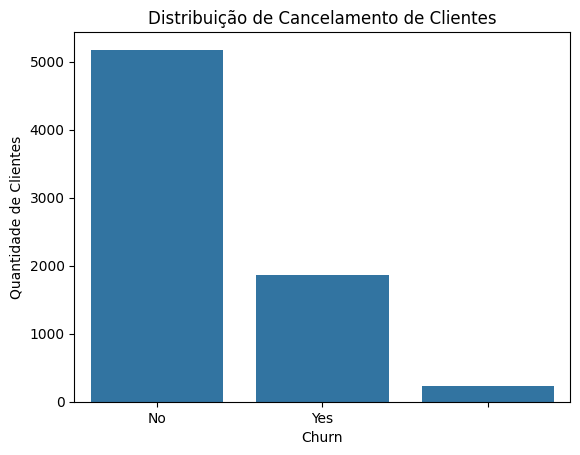

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.countplot(data=df, x='Churn')

plt.title('Distribuição de Cancelamento de Clientes')
plt.xlabel('Churn')
plt.ylabel('Quantidade de Clientes')

plt.show()


In [ ]:
plt.figure()

sns.countplot(data=df, x='Contract', hue='Churn')

plt.title('Cancelamento por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade')

plt.show()


ValueError: Could not interpret value `Contract` for `x`. An entry with this name does not appear in `data`.

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure()

sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)

plt.title('Tempo de Contrato vs Cancelamento')
plt.xlabel('Meses como cliente')
plt.ylabel('Quantidade')

plt.show()


ValueError: Could not interpret value `tenure` for `x`. An entry with this name does not appear in `data`.

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure()

sns.boxplot(data=df, x='Churn', y='Charges.Monthly')

plt.title('Valor Mensal vs Cancelamento')
plt.xlabel('Churn')
plt.ylabel('Cobrança Mensal')

plt.show()


ValueError: Could not interpret value `Charges.Monthly` for `y`. An entry with this name does not appear in `data`.

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure()

sns.countplot(data=df, x='InternetService', hue='Churn')

plt.title('Cancelamento por Tipo de Internet')
plt.xlabel('Tipo de Internet')
plt.ylabel('Quantidade')

plt.show()


ValueError: Could not interpret value `InternetService` for `x`. An entry with this name does not appear in `data`.

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure()

correlacao = df[['tenure', 'Charges.Monthly', 'Charges.Total']].corr()

sns.heatmap(correlacao, annot=True)

plt.title('Correlação entre Variáveis Numéricas')

plt.show()


KeyError: "None of [Index(['tenure', 'Charges.Monthly', 'Charges.Total'], dtype='object')] are in the [columns]"

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure()

sns.countplot(data=df, x='PaymentMethod', hue='Churn')

plt.title('Cancelamento por Método de Pagamento')
plt.xlabel('Método de Pagamento')
plt.ylabel('Quantidade')

plt.xticks(rotation=45)

plt.show()


ValueError: Could not interpret value `PaymentMethod` for `x`. An entry with this name does not appear in `data`.

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# calcular taxa de churn
churn_contract = (
    df.groupby('Contract')['Churn']
    .value_counts(normalize=True)
    .rename('percent')
    .mul(100)
    .reset_index()
)

# filtrar apenas churn = Yes
churn_contract = churn_contract[churn_contract['Churn'] == 'Yes']

plt.figure()

sns.barplot(data=churn_contract, x='Contract', y='percent')

plt.title('Taxa de Churn (%) por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Taxa de Churn (%)')

plt.show()
``


SyntaxError: invalid syntax (3841276007.py, line 25)

In [ ]:
churn_internet = (
    df.groupby('InternetService')['Churn']
    .value_counts(normalize=True)
    .rename('percent')
    .mul(100)
    .reset_index()
)

churn_internet = churn_internet[churn_internet['Churn'] == 'Yes']

plt.figure()

sns.barplot(data=churn_internet, x='InternetService', y='percent')

plt.title('Taxa de Churn (%) por Tipo de Internet')
plt.xlabel('Tipo de Internet')
plt.ylabel('Taxa de Churn (%)')

plt.show()


KeyError: 'InternetService'

In [ ]:
servicos = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

dados_heatmap = []

for servico in servicos:

    taxa = (
        df.groupby(servico)['Churn']
        .value_counts(normalize=True)
        .rename('percent')
        .mul(100)
        .reset_index()
    )

    taxa = taxa[ taxa['Churn'] == 'Yes' ]

    taxa['Service'] = servico

    dados_heatmap.append(taxa)

heatmap_df = pd.concat(dados_heatmap)

pivot = heatmap_df.pivot(index='Service', columns=servico, values='percent')

plt.figure()

sns.heatmap(pivot, annot=True)

plt.title('Taxa de Churn por Serviços Adicionais')

plt.show()


KeyError: 'OnlineSecurity'

In [ ]:
1 - Importação das bibliotecas
2 - Coleta de dados (API)
3 - Tratamento de dados (ETL)
4 - Exploração inicial
5 - Análise exploratória (EDA)
      • distribuição churn
      • churn por contrato
      • churn por internet
      • churn por serviços
      • churn por tempo
6 - Insights estratégicos


SyntaxError: invalid character '•' (U+2022) (676928980.py, line 6)

# 12. Insights

O dataset contém informações demográficas, serviços contratados e dados financeiros dos clientes da Telecom X. A variável Churn indica se o cliente cancelou o serviço.

A análise inicial mostra que fatores como tempo de contrato (tenure), tipo de contrato, serviços adicionais e valor mensal pago podem influenciar diretamente a evasão de clientes.